In [9]:
# ==========================================
# IMPORT LIBRARIES
# ==========================================
# Här laddar vi in de bibliotek som behövs för:
# - datahantering
# - statistik
# - visualisering
# - datareduktion

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer

import umap.umap_ as umap

# Gör plots lite snyggare
sns.set(style="whitegrid")

In [10]:
# ==========================================
# LOAD DATA
# ==========================================
# Vi läser in det första datasetet som redan finns i projektmappen.

df = pd.read_csv("../data/exercise_dataset.csv")

# Visa de första raderna
df.head()

,ID,Exercise,Calories Burn,Dream Weight,Actual Weight,Age,Gender,Duration,Heart Rate,BMI,Weather Conditions,Exercise Intensity
0,1,Exercise 2,286.959851,91.892531,96.301115,45,Male,37,170,29.426275,Rainy,5
1,2,Exercise 7,343.453036,64.165097,61.104668,25,Male,43,142,21.286346,Rainy,5
2,3,Exercise 4,261.223465,70.846224,71.766724,20,Male,20,148,27.899592,Cloudy,4
3,4,Exercise 5,127.183858,79.477008,82.984456,33,Male,39,170,33.729552,Sunny,10
4,5,Exercise 10,416.318374,89.960226,85.643174,29,Female,34,118,23.286113,Cloudy,3


In [11]:
# ==========================================
# DATA OVERVIEW
# ==========================================
# Här skaffar vi en snabb överblick:
# - hur stort datasetet är
# - vilka kolumner det innehåller
# - vilka datatyper som finns
# - om det finns missing values

print("Shape (rows, columns):", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nInfo:")
df.info()

print("\nMissing values per column:")
print(df.isna().sum())

Shape (rows, columns): (3864, 12)

Columns:
['ID', 'Exercise', 'Calories Burn', 'Dream Weight', 'Actual Weight', 'Age', 'Gender', 'Duration', 'Heart Rate', 'BMI', 'Weather Conditions', 'Exercise Intensity']

Info:
<class 'pandas.DataFrame'>
RangeIndex: 3864 entries, 0 to 3863
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  3864 non-null   int64  
 1   Exercise            3864 non-null   str    
 2   Calories Burn       3864 non-null   float64
 3   Dream Weight        3864 non-null   float64
 4   Actual Weight       3864 non-null   float64
 5   Age                 3864 non-null   int64  
 6   Gender              3864 non-null   str    
 7   Duration            3864 non-null   int64  
 8   Heart Rate          3864 non-null   int64  
 9   BMI                 3864 non-null   float64
 10  Weather Conditions  3864 non-null   str    
 11  Exercise Intensity  3864 non-null   int64  
dtyp

In [12]:
# ==========================================
# SELECT VARIABLES FOR SPIRIT ANALYSIS
# ==========================================
# Här väljer vi många variabler så att datareduktionen blir meningsfull.
# Vi vill fånga:
# - träningspassets karaktär
# - klientens nuläge
# - träningsmål
# - kaloriförbränning

spirit_numeric_features = [
    "Calories Burn",
    "Actual Weight",
    "Dream Weight",
    "Age",
    "Duration",
    "Heart Rate",
    "BMI",
    "Exercise Intensity"
]

spirit_categorical_features = [
    "Exercise",
    "Gender",
    "Weather Conditions"
]

df_spirit = df[spirit_numeric_features + spirit_categorical_features].copy()

df_spirit.head()

,Calories Burn,Actual Weight,Dream Weight,Age,Duration,Heart Rate,BMI,Exercise Intensity,Exercise,Gender,Weather Conditions
0,286.959851,96.301115,91.892531,45,37,170,29.426275,5,Exercise 2,Male,Rainy
1,343.453036,61.104668,64.165097,25,43,142,21.286346,5,Exercise 7,Male,Rainy
2,261.223465,71.766724,70.846224,20,20,148,27.899592,4,Exercise 4,Male,Cloudy
3,127.183858,82.984456,79.477008,33,39,170,33.729552,10,Exercise 5,Male,Sunny
4,416.318374,85.643174,89.960226,29,34,118,23.286113,3,Exercise 10,Female,Cloudy


In [13]:
# ==========================================
# DESCRIPTIVE STATISTICS
# ==========================================
# Här tar vi fram grundläggande statistik för de numeriska variablerna.
# Det hjälper oss se nivåer, spridning och rimlighet i datan.

df_spirit[spirit_numeric_features].describe()

,Calories Burn,Actual Weight,Dream Weight,Age,Duration,Heart Rate,BMI,Exercise Intensity
count,3864.000000,3864.000000,3864.000000,3864.000000,3864.000000,3864.000000,3864.000000,3864.000000
mean,301.861806,75.188440,75.139263,39.621118,40.190994,139.777950,26.801977,5.457298
std,115.828604,14.845511,14.545824,12.521721,11.765957,23.447528,4.746745,2.850896
min,100.009403,45.783747,50.001984,18.000000,20.000000,100.000000,18.500014,1.000000
25%,202.168837,62.476906,62.373585,29.000000,30.000000,119.000000,22.686774,3.000000
50%,299.742508,75.544407,75.522136,40.000000,40.000000,140.000000,26.861656,5.000000
75%,404.143688,88.105767,87.707989,51.000000,51.000000,160.000000,30.950380,8.000000
max,499.859262,104.309600,99.985355,60.000000,60.000000,180.000000,34.996639,10.000000


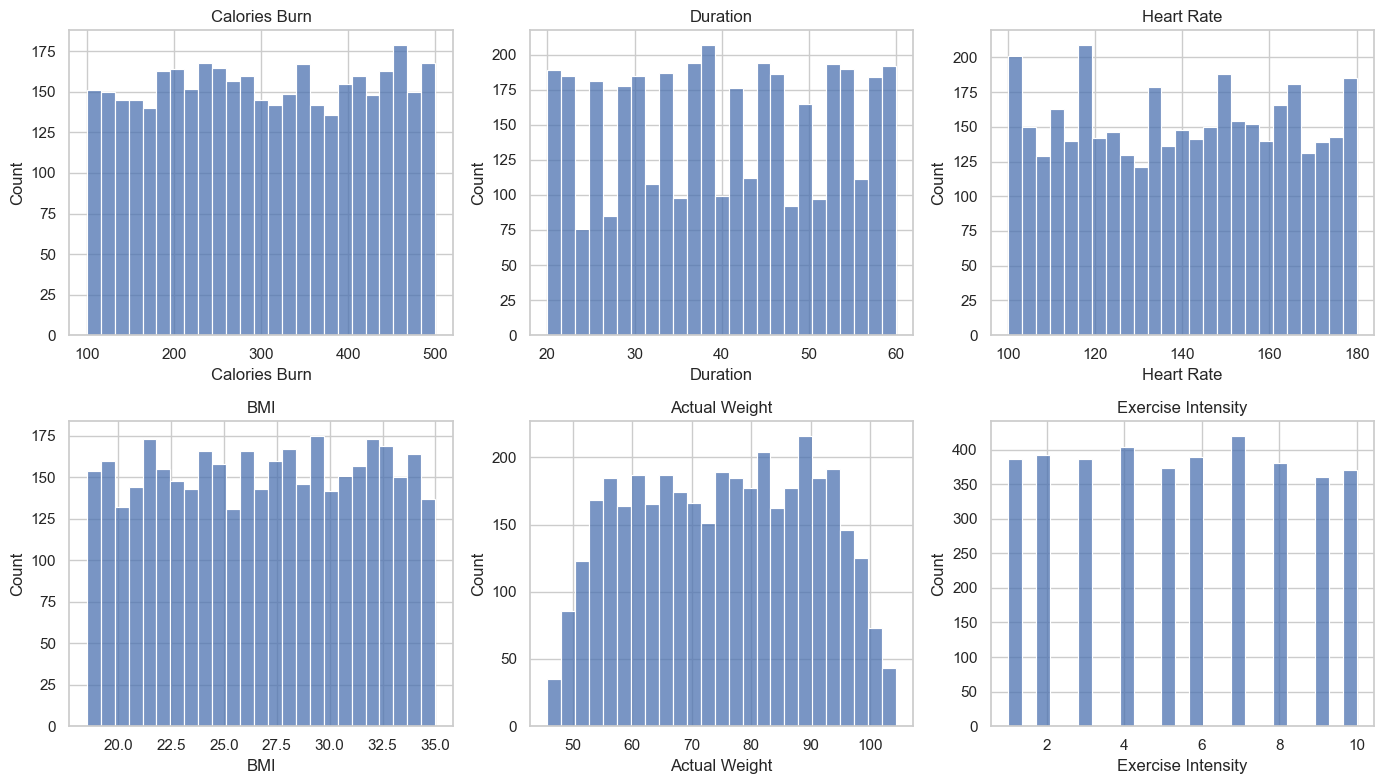

In [14]:
# ==========================================
# DISTRIBUTIONS
# ==========================================
# Här visar vi hur några centrala variabler är fördelade.
# Detta hjälper oss förstå om datan verkar jämn, sned eller har extrema värden.

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

plot_features = [
    "Calories Burn",
    "Duration",
    "Heart Rate",
    "BMI",
    "Actual Weight",
    "Exercise Intensity"
]

for ax, col in zip(axes.flatten(), plot_features):
    sns.histplot(df_spirit[col], bins=25, ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

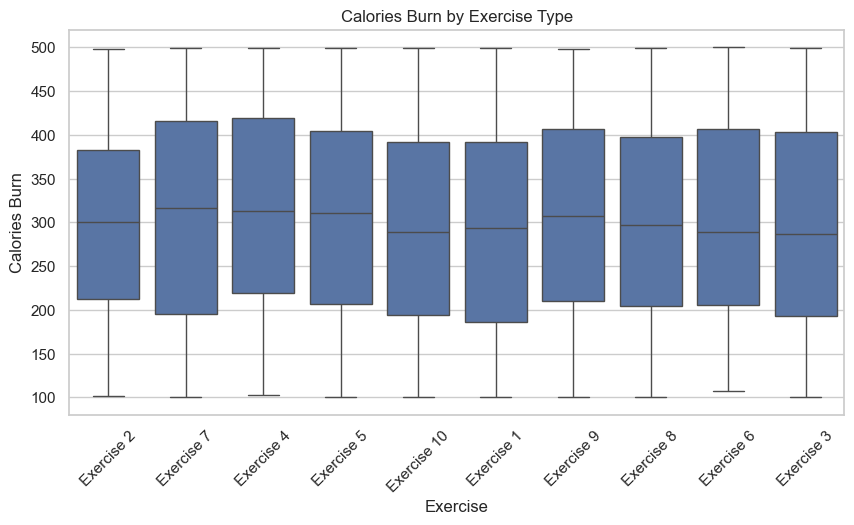

In [15]:
# ==========================================
# CALORIES BURN BY EXERCISE TYPE
# ==========================================
# Här undersöker vi om olika träningsformer verkar kopplas till olika nivåer av kaloriförbränning.

plt.figure(figsize=(10, 5))
sns.boxplot(x="Exercise", y="Calories Burn", data=df_spirit)
plt.xticks(rotation=45)
plt.title("Calories Burn by Exercise Type")
plt.show()

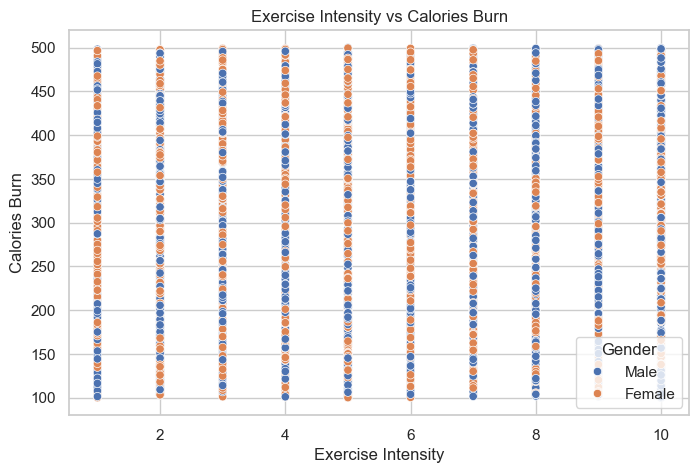

In [16]:
# ==========================================
# EXERCISE INTENSITY VS CALORIES BURN
# ==========================================
# Här tittar vi på om högre träningsintensitet verkar hänga ihop med högre kaloriförbränning.

plt.figure(figsize=(8, 5))
sns.scatterplot(
    x="Exercise Intensity",
    y="Calories Burn",
    hue="Gender",
    data=df_spirit
)
plt.title("Exercise Intensity vs Calories Burn")
plt.show()

In [17]:
# ==========================================
# INTERACTIVE VISUALIZATION
# ==========================================
# Detta är en interaktiv plot som uppfyller lärarens extra-del.
# Här kan användaren hovra över punkterna och få mer information.

fig = px.scatter(
    df_spirit,
    x="Exercise Intensity",
    y="Calories Burn",
    color="Exercise",
    hover_data=["Gender", "Age", "Duration", "BMI"],
    title="Interactive: Exercise Intensity vs Calories Burn"
)

fig.show()

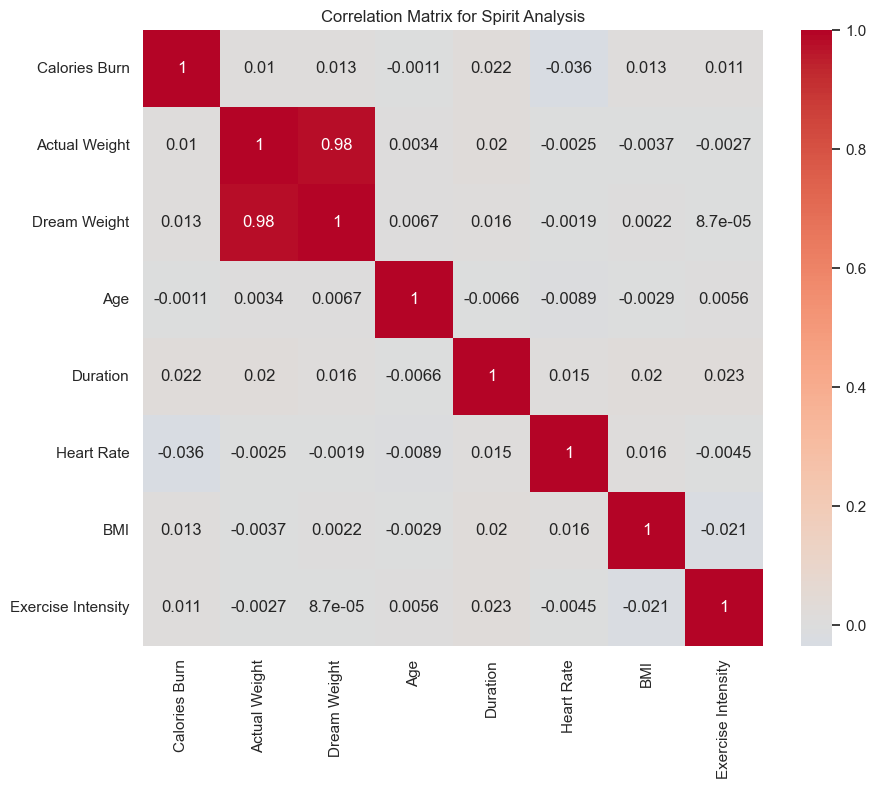

In [18]:
# ==========================================
# CORRELATION MATRIX
# ==========================================
# Här tittar vi på linjära samband mellan numeriska variabler.
# Det hjälper oss förstå om vissa variabler verkar överlappa eller röra sig tillsammans.

plt.figure(figsize=(10, 8))
corr_matrix = df_spirit[spirit_numeric_features].corr(numeric_only=True)

sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Matrix for Spirit Analysis")
plt.show()

In [19]:
# ==========================================
# PREPARE DATA FOR PCA AND UMAP
# ==========================================
# PCA och UMAP behöver numerisk data utan tomma värden.
# Därför:
# 1. väljer vi bara numeriska features
# 2. fyller eventuella missing values med median
# 3. standardiserar datan så att alla variabler hamnar på jämförbar skala

X = df_spirit[spirit_numeric_features].copy()

# Fyll missing values med median
imputer = SimpleImputer(strategy="median")
X_imputed = imputer.fit_transform(X)

# Standardisera datan
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

print("Shape of analysis matrix:", X_scaled.shape)

Shape of analysis matrix: (3864, 8)


In [20]:
# ==========================================
# PCA - ALL COMPONENTS
# ==========================================
# Här ber vi PCA räkna ut alla komponenter först.
# Målet är att se hur mycket variation varje komponent förklarar.

pca = PCA()
X_pca_all = pca.fit_transform(X_scaled)

explained_variance = pca.explained_variance_ratio_
explained_variance_cumsum = np.cumsum(explained_variance)

print("Explained variance ratio per component:")
print(explained_variance)

print("\nCumulative explained variance:")
print(explained_variance_cumsum)

Explained variance ratio per component:
[0.24780178 0.13047618 0.12960905 0.12699673 0.12470523 0.11951991
 0.11856845 0.00232267]

Cumulative explained variance:
[0.24780178 0.37827796 0.50788701 0.63488374 0.75958897 0.87910888
 0.99767733 1.        ]


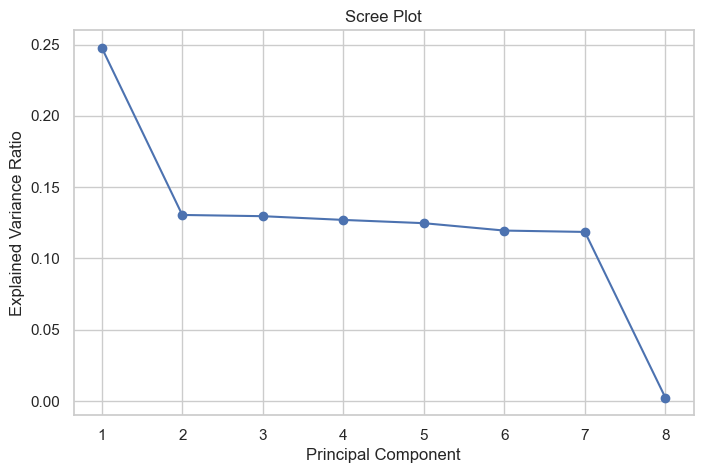

In [21]:
# ==========================================
# SCREE PLOT
# ==========================================
# Scree plot hjälper oss avgöra hur många komponenter som verkar rimliga att behålla.

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(explained_variance) + 1), explained_variance, marker="o")
plt.title("Scree Plot")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.xticks(range(1, len(explained_variance) + 1))
plt.grid(True)
plt.show()

In [22]:
# ==========================================
# PCA TO 2 COMPONENTS
# ==========================================
# Här reducerar vi datan till två komponenter för att kunna visualisera den i 2D.

pca_2 = PCA(n_components=2)
X_pca_2 = pca_2.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca_2, columns=["PC1", "PC2"])

# Lägg tillbaka några variabler för tolkning
pca_df["Calories Burn"] = df_spirit["Calories Burn"].values
pca_df["Exercise"] = df_spirit["Exercise"].values
pca_df["Gender"] = df_spirit["Gender"].values

pca_df.head()

,PC1,PC2,Calories Burn,Exercise,Gender
0,1.808394,-0.917439,286.959851,Exercise 2,Male
1,-1.199253,0.173574,343.453036,Exercise 7,Male
2,-0.435119,-1.349520,261.223465,Exercise 4,Male
3,0.542817,-1.118053,127.183858,Exercise 5,Male
4,1.219447,0.501739,416.318374,Exercise 10,Female


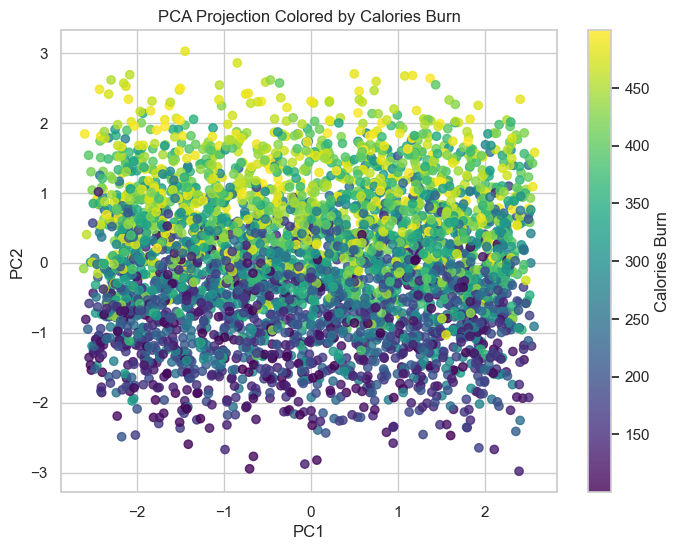

In [23]:
# ==========================================
# PCA PROJECTION COLORED BY CALORIES
# ==========================================
# Här ser vi om den reducerade strukturen verkar hänga ihop med kaloriförbränning.

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=pca_df["Calories Burn"],
    cmap="viridis",
    alpha=0.8
)

plt.colorbar(scatter, label="Calories Burn")
plt.title("PCA Projection Colored by Calories Burn")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.show()

In [24]:
# ==========================================
# VARIABLE CONTRIBUTIONS (PCA LOADINGS)
# ==========================================
# PCA loadings visar vilka variabler som bidrar mest till de nya komponenterna.
# Detta uppfyller lärarens extra-del om att undersöka bidrag av olika variabler.

loadings = pd.DataFrame(
    pca_2.components_.T,
    columns=["PC1_loading", "PC2_loading"],
    index=spirit_numeric_features
)

loadings

,PC1_loading,PC2_loading
Calories Burn,0.017378,0.664009
Actual Weight,0.706743,-0.016412
Dream Weight,0.706712,-0.015502
Age,0.007064,0.087412
Duration,0.026590,0.340978
Heart Rate,-0.003459,-0.501372
BMI,-0.000340,-0.038239
Exercise Intensity,-0.000976,0.426426


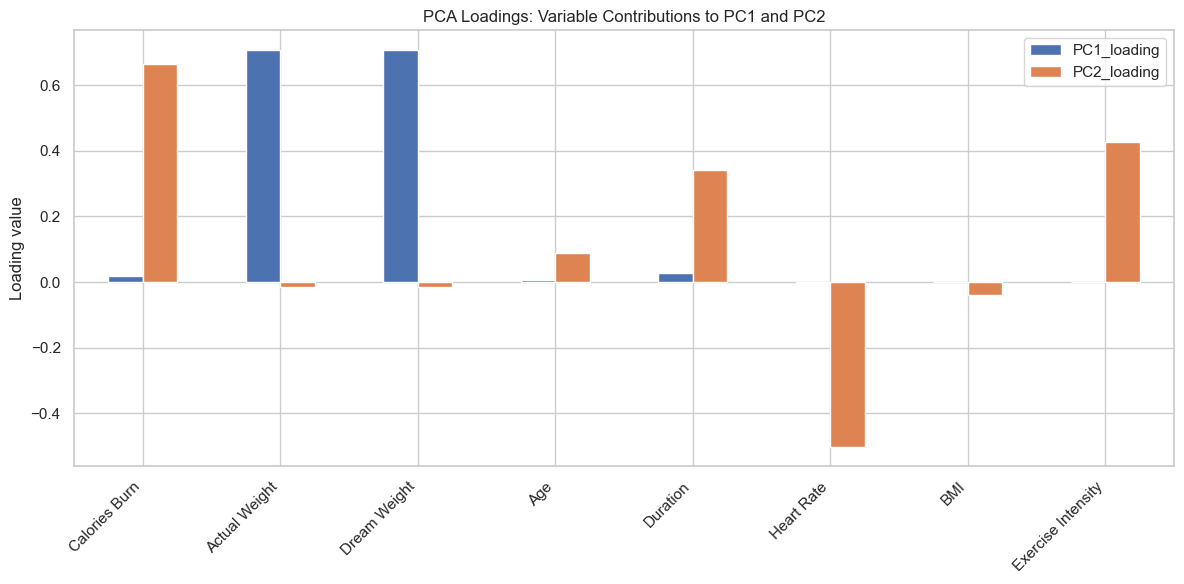

In [25]:
# ==========================================
# VISUALIZE VARIABLE CONTRIBUTIONS
# ==========================================
# Här ser vi tydligare vilka ursprungsvariabler som driver PC1 och PC2.

loadings.plot(kind="bar", figsize=(12, 6))
plt.title("PCA Loadings: Variable Contributions to PC1 and PC2")
plt.ylabel("Loading value")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [26]:
# ==========================================
# INTERACTIVE PCA
# ==========================================
# Interaktiv PCA-visualisering som gör det lättare att utforska punkterna.
# Detta kan vara bra i både analys och presentation.

fig = px.scatter(
    pca_df,
    x="PC1",
    y="PC2",
    color="Calories Burn",
    hover_data=["Exercise", "Gender", "Calories Burn"],
    title="Interactive PCA Projection Colored by Calories Burn",
    color_continuous_scale="viridis"
)

fig.show()

In [27]:
# ==========================================
# UMAP BASE MODEL
# ==========================================
# UMAP är en icke-linjär datareduktionsteknik.
# Den försöker bevara likhet mellan observationer när datan trycks ned till 2D.

umap_model = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    random_state=42
)

X_umap = umap_model.fit_transform(X_scaled)

umap_df = pd.DataFrame(X_umap, columns=["UMAP1", "UMAP2"])
umap_df["Calories Burn"] = df_spirit["Calories Burn"].values
umap_df["Exercise"] = df_spirit["Exercise"].values
umap_df["Gender"] = df_spirit["Gender"].values

umap_df.head()

c:\Users\spiri\ws\fitness-anomaly-detector\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


,UMAP1,UMAP2,Calories Burn,Exercise,Gender
0,1.054106,4.894616,286.959851,Exercise 2,Male
1,6.055743,5.204716,343.453036,Exercise 7,Male
2,5.993397,5.115552,261.223465,Exercise 4,Male
3,3.665603,6.825593,127.183858,Exercise 5,Male
4,3.184480,4.800906,416.318374,Exercise 10,Female


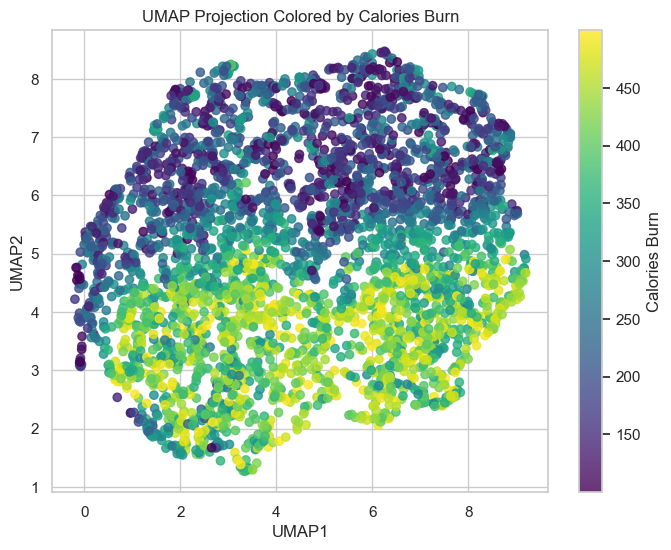

In [28]:
# ==========================================
# UMAP PROJECTION
# ==========================================
# Här ser vi om UMAP visar mer komplexa mönster eller möjliga träningsprofiler.

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    umap_df["UMAP1"],
    umap_df["UMAP2"],
    c=umap_df["Calories Burn"],
    cmap="viridis",
    alpha=0.8
)

plt.colorbar(scatter, label="Calories Burn")
plt.title("UMAP Projection Colored by Calories Burn")
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.grid(True)
plt.show()

c:\Users\spiri\ws\fitness-anomaly-detector\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\spiri\ws\fitness-anomaly-detector\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\spiri\ws\fitness-anomaly-detector\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


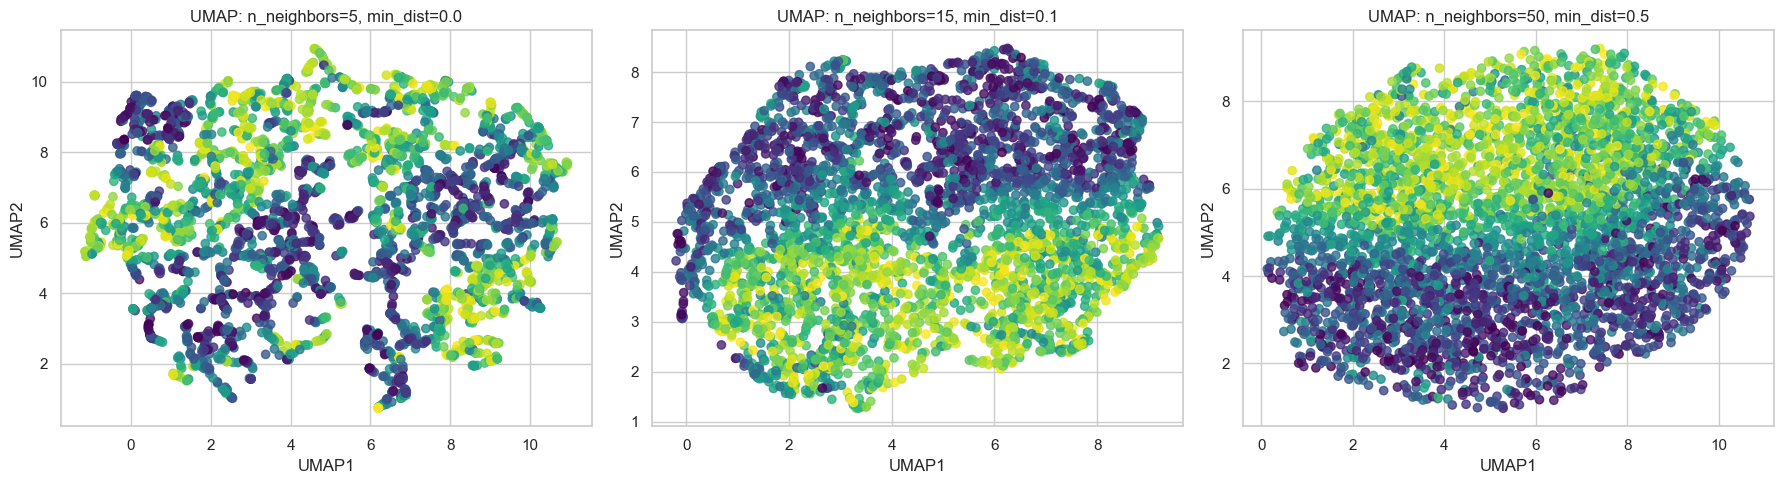

In [29]:
# ==========================================
# UMAP HYPERPARAMETER TUNING
# ==========================================
# Här testar vi olika UMAP-inställningar.
# Detta är exakt vad läraren menar med hyperparameter justering.

param_grid = [
    {"n_neighbors": 5, "min_dist": 0.0},
    {"n_neighbors": 15, "min_dist": 0.1},
    {"n_neighbors": 50, "min_dist": 0.5},
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, params in zip(axes, param_grid):
    model = umap.UMAP(
        n_neighbors=params["n_neighbors"],
        min_dist=params["min_dist"],
        random_state=42
    )
    
    X_umap_temp = model.fit_transform(X_scaled)
    
    sc = ax.scatter(
        X_umap_temp[:, 0],
        X_umap_temp[:, 1],
        c=df_spirit["Calories Burn"],
        cmap="viridis",
        alpha=0.8
    )
    
    ax.set_title(
        f'UMAP: n_neighbors={params["n_neighbors"]}, min_dist={params["min_dist"]}'
    )
    ax.set_xlabel("UMAP1")
    ax.set_ylabel("UMAP2")

plt.tight_layout()
plt.show()

In [30]:
# ==========================================
# INTERACTIVE UMAP
# ==========================================
# Interaktiv UMAP-plot som kan användas som extra visualisering eller demo.

fig = px.scatter(
    umap_df,
    x="UMAP1",
    y="UMAP2",
    color="Calories Burn",
    hover_data=["Exercise", "Gender", "Calories Burn"],
    title="Interactive UMAP Projection Colored by Calories Burn",
    color_continuous_scale="viridis"
)

fig.show()

In [31]:
# ==========================================
# SUMMARY / INTERPRETATION PROMPTS
# ==========================================
# Den här cellen hjälper dig formulera slutsatser till notebooken och presentationen.

print("Questions to answer after the analysis:")
print("- Which exercise patterns seem linked to higher calories burned?")
print("- Do PCA and UMAP reveal structure in the data?")
print("- Which variables contribute most to PCA?")
print("- Does UMAP show more complex patterns than PCA?")
print("- Which UMAP setting seems most pedagogically useful?")

Questions to answer after the analysis:
- Which exercise patterns seem linked to higher calories burned?
- Do PCA and UMAP reveal structure in the data?
- Which variables contribute most to PCA?
- Does UMAP show more complex patterns than PCA?
- Which UMAP setting seems most pedagogically useful?
